# Лингвистические маркеры модальности

Конфигурация: указать нужные пути к папкам

In [2]:
JSON_FOLDER = "/content/drive/MyDrive/ВЫБОРКА"
OUTPUT_FILE = "/content/drive/MyDrive/linguistic_markers_res.csv"
INPUT_FILE = "/content/drive/MyDrive/анализ отчетов/linguistic_markers_res.csv"
SIMILARITY_FILE = "/content/drive/MyDrive/анализ отчетов/косинусная близость отчетов.csv"

Подсчет маркеров модальности

In [6]:
import os
import json
import re
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

modals = [
    "may", "might", "could", "would",
    "expect", "expects", "expected",
    "anticipate", "anticipates", "anticipated",
    "believe", "believes", "believed",
    "potential", "possible", "possibly",
    "uncertain", "uncertainty",
    "risk", "risks", "risky",
    "likely", "unlikely",
    "assume", "assumes", "assumed",
    "estimate", "estimates", "estimated",
    "forecast", "forecasts", "forecasted",
    "project", "projects", "projected",
    "plan", "plans", "planned",
    "intend", "intends", "intended",
    "seek", "seeks",
    "continue", "continues", "continued",
    "future", "forward",
    "opportunity", "opportunities",
    "challenge", "challenges",
    "threat", "threats",
    "volatile", "volatility",
    "unclear", "unknown",
    "subject", "depending",
    "assumption", "assumptions"
]

results_markers = [
    "achieved", "improved", "improvement",
    "increased", "increase",
    "decreased", "decrease",
    "generated", "generate",
    "completed", "complete",
    "delivered", "deliver",
    "resulted", "resulting",
    "grew", "growth",
    "expanded", "expansion",
    "reduced", "reduction",
    "performed", "performance",
    "reported", "reporting",
    "reached", "maintained",
    "success", "successful", "successfully",
    "strong", "stronger",
    "record", "recorded",
    "profit", "profits", "profitable",
    "revenue", "revenues",
    "earnings", "income",
    "cash", "cashflow",
    "efficiency", "efficient",
    "benefit", "benefits",
    "gain", "gains",
    "improve", "improving",
    "deliverable", "delivery",
    "operational", "operations",
    "growth rate",
    "outperformed",
    "stabilized", "stability",
    "optimized", "optimization",
    "innovation", "innovative",
    "leader", "leadership",
    "value", "valuable",
    "achievement", "achievements"
]

def tokenize(text):
    text = str(text).lower()
    return re.findall(r'\b[a-z]+\b', text)

def marker_ratio(text, markers):
    tokens = tokenize(text)
    if len(tokens) == 0:
        return 0
    marker_count = sum(1 for token in tokens if token in markers)
    return marker_count / len(tokens)

data = []

for file in os.listdir(JSON_FOLDER):
    if file.endswith(".json"):
        path = os.path.join(JSON_FOLDER, file)
        with open(path, "r", encoding="utf-8") as f:
            try:
                j = json.load(f)

                company = str(j.get("company", "")).lower()
                if not company:
                    company = file.split("-")[0].lower()

                year = j.get("fiscal_year")
                if year is None:
                    year = 0
                else:
                    year = int(year)

                section_1a = j.get("section_item_1a", "")
                section_7 = j.get("section_item_7", "")

                modal_ratio_1A = marker_ratio(section_1a, modals)
                modal_ratio_7 = marker_ratio(section_7, modals)

                result_ratio_1A = marker_ratio(section_1a, results_markers)
                result_ratio_7 = marker_ratio(section_7, results_markers)

                data.append({
                    "company": company,
                    "year": year,
                    "modal_ratio_1A": modal_ratio_1A,
                    "modal_ratio_7": modal_ratio_7,
                    "result_ratio_1A": result_ratio_1A,
                    "result_ratio_7": result_ratio_7
                })

            except Exception as e:
                print("ERROR:", file, e)

df = pd.DataFrame(data)

df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv(INPUT_FILE, sep=';', encoding='utf-8-sig')

try:
    sim_df = pd.read_csv(SIMILARITY_FILE, sep=';', encoding='utf-8-sig')

    if len(sim_df.columns) == 1:
        col_name = sim_df.columns[0]
        sim_df = sim_df[col_name].str.split(',', expand=True)
        sim_df.columns = ['company', 'year', 'similarity_1_7', 'similarity_1A_7']

    sim_df['company'] = sim_df['company'].astype(str).str.lower()
    sim_df['year'] = sim_df['year'].astype(int)
    sim_df['similarity_1_7'] = sim_df['similarity_1_7'].astype(float)
    sim_df['similarity_1A_7'] = sim_df['similarity_1A_7'].astype(float)
    sim_df['gap'] = sim_df['similarity_1_7'] - sim_df['similarity_1A_7']

    df = pd.merge(df, sim_df[['company', 'year', 'similarity_1_7', 'similarity_1A_7', 'gap']],
                  on=['company', 'year'], how='left')

except Exception as e:
    print(f"не удалось загрузить cosine similarity: {e}")
    df['gap'] = None

print("метрики по компаниям".center(80))
company_summary = df.groupby('company').agg({
    'modal_ratio_1A': 'mean',
    'modal_ratio_7': 'mean',
    'result_ratio_1A': 'mean',
    'result_ratio_7': 'mean',
    'gap': 'mean'
}).round(4).reset_index()

company_summary.columns = [
    'company',
    'modal_ratio_risks',
    'modal_ratio_results',
    'result_ratio_risks',
    'result_ratio_results',
    'gap (косинусной близости пар разделов)'
]
company_summary['average'] = company_summary[['modal_ratio_risks', 'modal_ratio_results', 'result_ratio_risks', 'result_ratio_results']].mean(axis=1)
company_summary = company_summary.sort_values('average', ascending=False)
company_summary = company_summary.drop('average', axis=1)

print(company_summary.to_string(index=False))

avg_modal_risks = df['modal_ratio_1A'].mean()
avg_modal_results = df['modal_ratio_7'].mean()
avg_result_risks = df['result_ratio_1A'].mean()
avg_result_results = df['result_ratio_7'].mean()

print(f"\nсредние значения по компаниям")
print(f"неопределенность в рисках {avg_modal_risks:.4f}")
print(f"неопределенность в результатах {avg_modal_results:.4f}")
print(f"(разница {avg_modal_risks - avg_modal_results:.4f})")

print(f"\nрезультативность в рисках {avg_result_risks:.4f}")
print(f"результативность в результатах {avg_result_results:.4f}")
print(f"(разница {avg_result_results - avg_result_risks:.4f})")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                              метрики по компаниям                              
company  modal_ratio_risks  modal_ratio_results  result_ratio_risks  result_ratio_results  gap (косинусной близости пар разделов)
    unh             0.1051               0.0584              0.0132                0.0130                                 -0.4872
    fnm             0.0892               0.0266              0.0139                0.0326                                  0.1139
    tgt             0.0891               0.0129              0.0147                0.0439                                 -0.0225
   nvda             0.0902               0.0292              0.0145                0.0219                                  0.0856
    vlo             0.0443               0.0681              0.0190                0.0218                                 -0.2072
    dis   

Деление компаний на квадранты по неопределенности и результативности разделов отчетов "риски" и "результаты"

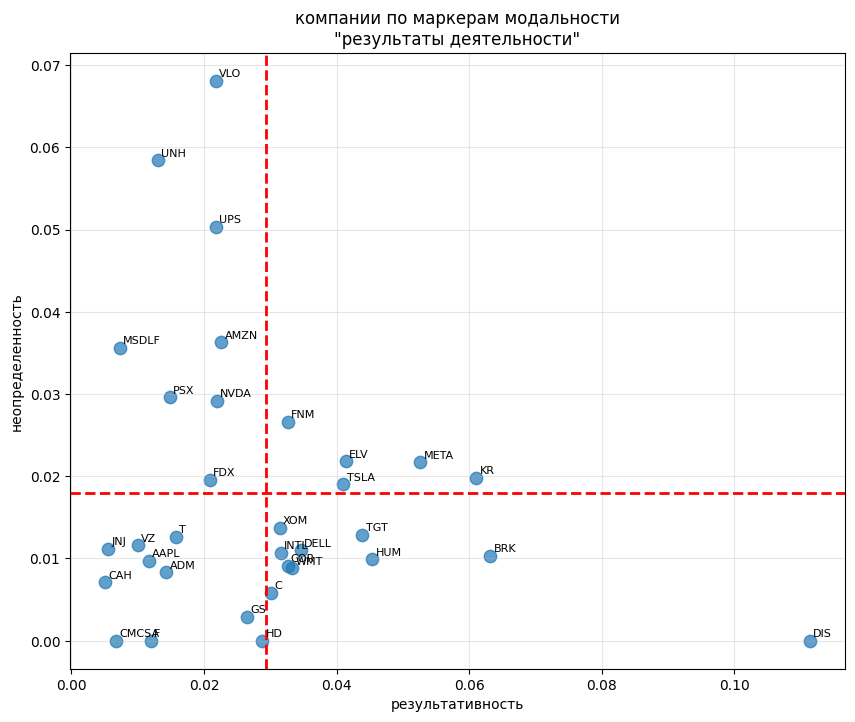

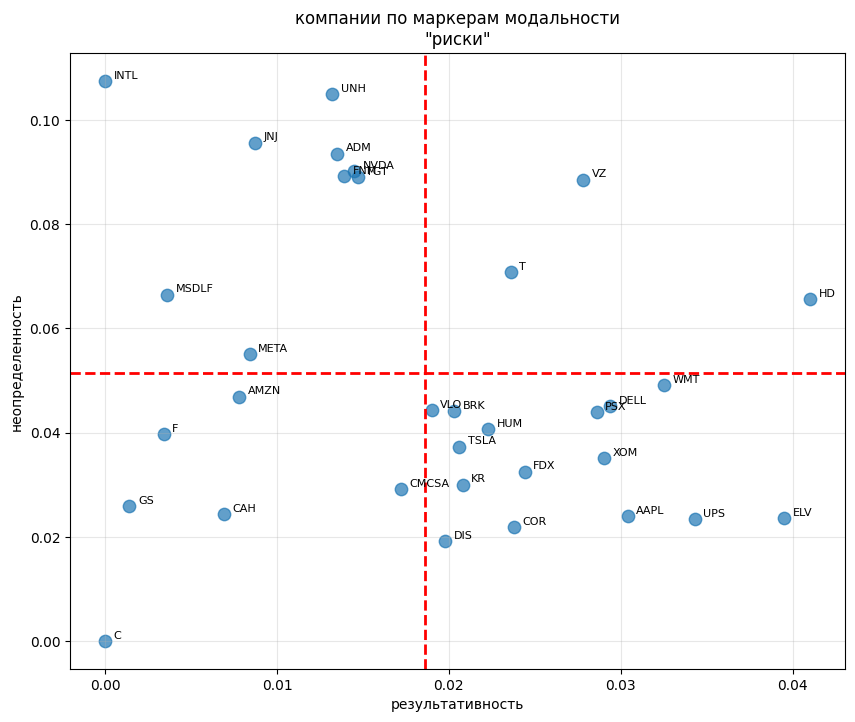

                       
кластеры: результаты деятельности                       

HIGH MODAL / LOW RESULT
['UNH', 'NVDA', 'VLO', 'UPS', 'PSX', 'AMZN', 'MSDLF', 'FDX']

HIGH MODAL / HIGH RESULT
['FNM', 'META', 'KR', 'ELV', 'TSLA']

LOW MODAL / HIGH RESULT
['TGT', 'DIS', 'INTL', 'BRK', 'WMT', 'DELL', 'HUM', 'XOM', 'COR', 'C']

LOW MODAL / LOW RESULT
['VZ', 'HD', 'ADM', 'T', 'JNJ', 'AAPL', 'GS', 'F', 'CMCSA', 'CAH']
                                
кластеры: риски                                

HIGH MODAL / LOW RESULT
['UNH', 'FNM', 'TGT', 'NVDA', 'INTL', 'META', 'ADM', 'JNJ', 'MSDLF']

LOW MODAL / HIGH RESULT
['VLO', 'DIS', 'BRK', 'KR', 'UPS', 'ELV', 'WMT', 'DELL', 'HUM', 'TSLA', 'PSX', 'XOM', 'FDX', 'COR', 'AAPL']

HIGH MODAL / HIGH RESULT
['VZ', 'HD', 'T']

LOW MODAL / LOW RESULT
['AMZN', 'GS', 'F', 'CMCSA', 'CAH', 'C']


In [11]:
import matplotlib.pyplot as plt

mean_modal_results = company_summary['modal_ratio_results'].mean()
mean_result_results = company_summary['result_ratio_results'].mean()

plt.figure(figsize=(10, 8))

plt.scatter(
    company_summary['result_ratio_results'],
    company_summary['modal_ratio_results'],
    s=80,
    alpha=0.7
)

for _, row in company_summary.iterrows():
    plt.text(
        row['result_ratio_results'] + 0.0005,
        row['modal_ratio_results'] + 0.0005,
        row['company'].upper(),
        fontsize=8
    )

plt.axvline(
    mean_result_results,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.axhline(
    mean_modal_results,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel('результативность')
plt.ylabel('неопределенность')
plt.title('компании по маркерам модальности\n"результаты деятельности"')
plt.grid(True, alpha=0.3)
plt.show()

mean_modal_risks = company_summary['modal_ratio_risks'].mean()
mean_result_risks = company_summary['result_ratio_risks'].mean()

plt.figure(figsize=(10, 8))

plt.scatter(
    company_summary['result_ratio_risks'],
    company_summary['modal_ratio_risks'],
    s=80,
    alpha=0.7
)

for _, row in company_summary.iterrows():
    plt.text(
        row['result_ratio_risks'] + 0.0005,
        row['modal_ratio_risks'] + 0.0005,
        row['company'].upper(),
        fontsize=8
    )

plt.axvline(
    mean_result_risks,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.axhline(
    mean_modal_risks,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel('результативность')
plt.ylabel('неопределенность')
plt.title('компании по маркерам модальности\n"риски"')
plt.grid(True, alpha=0.3)
plt.show()

def classify_company(modal, result, modal_mean, result_mean):
    if modal >= modal_mean and result >= result_mean:
        return "high modal / high result"
    elif modal >= modal_mean and result < result_mean:
        return "high modal / low result"
    elif modal < modal_mean and result >= result_mean:
        return "low modal / high result"
    else:
        return "low modal / low result"


company_summary['cluster_results'] = company_summary.apply(
    lambda row: classify_company(
        row['modal_ratio_results'],
        row['result_ratio_results'],
        mean_modal_results,
        mean_result_results
    ),
    axis=1
)

company_summary['cluster_risks'] = company_summary.apply(
    lambda row: classify_company(
        row['modal_ratio_risks'],
        row['result_ratio_risks'],
        mean_modal_risks,
        mean_result_risks
    ),
    axis=1
)

print("\nкластеры: результаты деятельности".center(80))

for cluster in company_summary['cluster_results'].unique():
    print(f"\n{cluster.upper()}")
    subset = company_summary[
        company_summary['cluster_results'] == cluster
    ]
    print(subset['company'].str.upper().tolist())

print("\nкластеры: риски".center(80))
for cluster in company_summary['cluster_risks'].unique():
    print(f"\n{cluster.upper()}")
    subset = company_summary[
        company_summary['cluster_risks'] == cluster
    ]
    print(subset['company'].str.upper().tolist())